# Multi-Agent Coordination using Tabular Q-Learning

## Objective

The objective of this project is to implement a multi-agent reinforcement learning system using Tabular Q-Learning.

Two autonomous agents (Type A and Type B) operate in the same 5×5 Grid World. Each agent learns independently to collect a sample and return it to its own base while avoiding collisions and adapting to the changing lake condition.

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
import time

from IPython.display import clear_output

## Project Constants

In [2]:
# Grid Size
GRID_SIZE = 5

# Total Episodes
EPISODES = 20000

# Maximum Steps per Episode
MAX_STEPS = 100

## Q-Learning Hyperparameters

In [3]:
# Learning Rate
ALPHA = 0.1

# Discount Factor
GAMMA = 0.95

# Exploration Rate
EPSILON = 1.0

# Exploration Decay
EPSILON_DECAY = 0.995

# Minimum Exploration
MIN_EPSILON = 0.01

## Fixed Locations

In [4]:
# Landing Pad X (West)
X_ROW = 2
X_COL = 0

# Landing Pad Y (North)
Y_ROW = 0
Y_COL = 2

# Sampling Site U (East)
U_ROW = 2
U_COL = 4

# Sampling Site V (South)
V_ROW = 4
V_COL = 2

## Lake Configuration

In [5]:
# Lake Position (Center)

LAKE_ROW = 2
LAKE_COL = 2

# Lake State

DRY = 0
FLOODED = 1

# Initial Lake State

lake_state = DRY

# Probability that the lake changes state
LAKE_FLIP_PROBABILITY = 0.2

## Action Space

In [6]:
ACTIONS = [
    "UP",
    "DOWN",
    "LEFT",
    "RIGHT",
    "WAIT"
]

TOTAL_ACTIONS = len(ACTIONS)

print(TOTAL_ACTIONS)

5


## State Representation

In [7]:
TOTAL_STATES = (
    GRID_SIZE *
    GRID_SIZE *
    2 *
    2
)

print("Total States:", TOTAL_STATES)

Total States: 100


## State Encoding Function

In [8]:
def state_to_index(
    row,
    col,
    has_sample,
    lake_state
):

    return (
        (
            (
                row * GRID_SIZE
                + col
            )
            * 2
            + int(has_sample)
        )
        * 2
        + lake_state
    )

## Initialize Q-Tables

In [9]:
q_table_A = np.zeros(
    (
        TOTAL_STATES,
        TOTAL_ACTIONS
    )
)

q_table_B = np.zeros(
    (
        TOTAL_STATES,
        TOTAL_ACTIONS
    )
)

print("Q-Table A:", q_table_A.shape)
print("Q-Table B:", q_table_B.shape)

Q-Table A: (100, 5)
Q-Table B: (100, 5)


## Environment Reset Function

In [10]:
def reset_environment():
    """
    Reset the environment before every episode.
    """

    # Agent A starts from X
    agent_a_row = X_ROW
    agent_a_col = X_COL

    # Agent B starts from Y
    agent_b_row = Y_ROW
    agent_b_col = Y_COL

    # Initially no agent has a sample
    agent_a_has_sample = False
    agent_b_has_sample = False

    # Randomly initialize lake state
    lake_state = random.choice([DRY, FLOODED])

    return (
        agent_a_row,
        agent_a_col,
        agent_b_row,
        agent_b_col,
        agent_a_has_sample,
        agent_b_has_sample,
        lake_state
    )

## Test Environment Reset

In [11]:
(
    agent_a_row,
    agent_a_col,
    agent_b_row,
    agent_b_col,
    agent_a_has_sample,
    agent_b_has_sample,
    lake_state
) = reset_environment()

print("Agent A :", (agent_a_row, agent_a_col))
print("Agent B :", (agent_b_row, agent_b_col))

print("Agent A Sample :", agent_a_has_sample)
print("Agent B Sample :", agent_b_has_sample)

print("Lake State :", "DRY" if lake_state == DRY else "FLOODED")

Agent A : (2, 0)
Agent B : (0, 2)
Agent A Sample : False
Agent B Sample : False
Lake State : FLOODED


## Lake Flip Function

In [12]:
def update_lake_state(current_state):
    """
    Update lake state with probability p.
    """

    if random.random() < LAKE_FLIP_PROBABILITY:

        if current_state == DRY:
            return FLOODED

        return DRY

    return current_state

## Test Lake Flip

In [13]:
lake = DRY

for i in range(10):

    lake = update_lake_state(lake)

    print(
        "Step",
        i + 1,
        ":",
        "DRY" if lake == DRY else "FLOODED"
    )

Step 1 : DRY
Step 2 : DRY
Step 3 : DRY
Step 4 : DRY
Step 5 : DRY
Step 6 : DRY
Step 7 : DRY
Step 8 : DRY
Step 9 : DRY
Step 10 : FLOODED


## Pickup Logic

In [14]:
def pickup_sample(
    row,
    col,
    has_sample,
    target_row,
    target_col
):

    if (
        row == target_row
        and
        col == target_col
    ):
        has_sample = True

    return has_sample

## Delivery Logic

In [15]:
def deliver_sample(
    row,
    col,
    has_sample,
    home_row,
    home_col
):

    if (
        row == home_row
        and
        col == home_col
        and
        has_sample
    ):

        has_sample = False

        return True, has_sample

    return False, has_sample

## Environment Helper Functions

In [16]:
def is_lake_cell(row, col):

    return (
        row == LAKE_ROW
        and
        col == LAKE_COL
    )

## Test Helper Function

In [17]:
print(is_lake_cell(2, 2))
print(is_lake_cell(1, 1))

True
False


# Q-Learning Training

## Initialize Training Variables

In [18]:
# Store total reward of every episode
episode_rewards = []

# Statistics
collision_count = 0
water_damage_count = 0

delivery_count_A = 0
delivery_count_B = 0

## Start Training Loop

In [19]:
for episode in range(EPISODES):
    
    (
        agent_a_row,
        agent_a_col,
        agent_b_row,
        agent_b_col,
        agent_a_has_sample,
        agent_b_has_sample,
        lake_state
    ) = reset_environment()
    
    total_reward_A = 0
    total_reward_B = 0

## Get Current State

In [20]:
# Current State of Agent A

state_A = state_to_index(
    agent_a_row,
    agent_a_col,
    agent_a_has_sample,
    lake_state
)

# Current State of Agent B

state_B = state_to_index(
    agent_b_row,
    agent_b_col,
    agent_b_has_sample,
    lake_state
)

## Verify Current States

In [21]:
print("Agent A State Index:", state_A)
print("Agent B State Index:", state_B)

Agent A State Index: 41
Agent B State Index: 9


## Epsilon-Greedy Action Selection
## Select Action for Agent A

In [22]:
## Agent A choose an action

if random.random() < EPISODES:
    
    action_A = random.randint(0, TOTAL_ACTIONS -1 )
    
else:
    
    action_A = np.argmax(q_table_A[state_A])

## Select Action for Agent B

In [23]:
# Agent B chooses an action

if random.random() < EPISODES:
    
    action_B = random.randint(0, TOTAL_ACTIONS - 1)
    
else:
    
    action_B = np.argmax(q_table_B[state_B])

## Verify Selected Actions

In [24]:
print("Agent A Action:", ACTIONS[action_A])
print("Agent B Action:", ACTIONS[action_B])

Agent A Action: DOWN
Agent B Action: WAIT


## Execute Joint Actions

In [25]:
# Next position of Agent A
next_a_row = agent_b_row
next_a_col = agent_b_col

# Next position of agent B
next_b_row = agent_b_row
next_b_col = agent_b_col

## Apply Actions

In [26]:
# ---------- Agent A ----------

if action_A == 0:
    next_a_row -= 1

elif action_A == 1:
    next_a_row += 1

elif action_A == 2:
    next_a_col -= 1

elif action_A == 3:
    next_a_col += 1

# WAIT
elif action_A == 4:
    pass


# ---------- Agent B ----------

if action_B == 0:
    next_b_row -= 1

elif action_B == 1:
    next_b_row += 1

elif action_B == 2:
    next_b_col -= 1

elif action_B == 3:
    next_b_col += 1

# WAIT
elif action_B == 4:
    pass

## Keep Agents Inside the Grid

In [27]:
next_a_row = max(0, min(next_a_row, GRID_SIZE - 1))
next_a_col = max(0, min(next_a_col, GRID_SIZE - 1))

next_b_row = max(0, min(next_b_row, GRID_SIZE - 1))
next_b_col = max(0, min(next_b_col, GRID_SIZE - 1))

## Update Agent Positions

In [28]:
agent_a_row = next_a_row
agent_a_col = next_a_col

agent_b_row = next_b_row
agent_b_col = next_b_col

## Reward System

In [29]:
# Initial reward for this step

reward_A = 0
reward_B = 0

## Step and Wait Rewards

In [30]:
# ---------- Agent A ----------

if action_A == 4:
    reward_A += -3
else:
    reward_A += -5


# ---------- Agent B ----------

if action_B == 4:
    reward_B += -3
else:
    reward_B += -5

## Pickup Reward

In [31]:
# ---------- Agent A ----------

if (
    agent_a_row == U_ROW
    and
    agent_a_col == U_COL
    and
    not agent_a_has_sample
):

    agent_a_has_sample = True

    reward_A += 10


# ---------- Agent B ----------

if (
    agent_b_row == V_ROW
    and
    agent_b_col == V_COL
    and
    not agent_b_has_sample
):

    agent_b_has_sample = True

    reward_B += 10

## Delivery Reward

In [32]:
# ---------- Agent A ----------

delivered_A, agent_a_has_sample = deliver_sample(
    agent_a_row,
    agent_a_col,
    agent_a_has_sample,
    X_ROW,
    X_COL
)

if delivered_A:

    reward_A += 50

    delivery_count_A += 1


# ---------- Agent B ----------

delivered_B, agent_b_has_sample = deliver_sample(
    agent_b_row,
    agent_b_col,
    agent_b_has_sample,
    Y_ROW,
    Y_COL
)

if delivered_B:

    reward_B += 50

    delivery_count_B += 1

## Update Episode Rewards

In [33]:
total_reward_A += reward_A
total_reward_B += reward_B

## Collision Detection

In [34]:
collision = False

if (
    next_a_row == next_b_row
    and
    next_a_col == next_b_col
    and
    next_a_row == LAKE_ROW
    and
    next_a_col == LAKE_COL
):

    collision = True

## Apply Collision Penalty

In [35]:
if collision:

    reward_A -= 20
    reward_B -= 20

    collision_count += 1

## Verify Collision Status

In [36]:
if collision:
    print("💥 Collision Detected!")

## Water Damage Logic

In [37]:
# Water damage applies only to Agent A

if (
    lake_state == FLOODED
    and
    next_a_row == LAKE_ROW
    and
    next_a_col == LAKE_COL
):

    reward_A -= 20

    water_damage_count += 1

# Agent B is waterproof.
# No water damage penalty is applied.

## Verify Water Damage

In [38]:
if (
    lake_state == FLOODED
    and
    next_a_row == LAKE_ROW
    and
    next_a_col == LAKE_COL
):
    print("🌊 Agent A received water damage!")

## Get Next State

In [39]:
# Next state of agent A
next_state_A = state_to_index(
    agent_a_row,
    agent_a_col,
    agent_a_has_sample,
    lake_state
)
# Next state of agent B
next_state_B = state_to_index(
    agent_b_row,
    agent_b_col,
    agent_b_has_sample,
    lake_state
)

## Verify Next State

In [40]:
print("Next State A :", next_state_A)
print("Next State B :", next_state_B)

Next State A : 29
Next State B : 9


## Q-Table Update

In [41]:
# ---------- Agent A Q-Update ----------

best_next_action_A = np.max(q_table_A[next_state_A])

q_table_A[state_A][action_A] = (
    q_table_A[state_A][action_A]
    +
    ALPHA
    * (
        reward_A
        +
        GAMMA * best_next_action_A
        -
        q_table_A[state_A][action_A]
    )
)


# ---------- Agent B Q-Update ----------

best_next_action_B = np.max(q_table_B[next_state_B])

q_table_B[state_B][action_B] = (
    q_table_B[state_B][action_B]
    +
    ALPHA
    * (
        reward_B
        +
        GAMMA * best_next_action_B
        -
        q_table_B[state_B][action_B]
    )
)

## Epsilon Decay

In [42]:
# Store total reward of this episode
episode_rewards.append(
        (total_reward_A + total_reward_B) / 2
    )

    # Decay epsilon
if EPSILON > MIN_EPSILON:
        EPSILON *= EPSILON_DECAY
        EPSILON = max(EPSILON, MIN_EPSILON)

## Training Complete

In [43]:
print("✅ Training Completed!")

print(f"Final Epsilon: {EPSILON:.4f}")
print(f"Total Collisions: {collision_count}")
print(f"Water Damage Count: {water_damage_count}")
print(f"Agent A Deliveries: {delivery_count_A}")
print(f"Agent B Deliveries: {delivery_count_B}")

✅ Training Completed!
Final Epsilon: 0.9950
Total Collisions: 0
Water Damage Count: 0
Agent A Deliveries: 0
Agent B Deliveries: 0


# Testing Trained Agents
## Initialize Testing Environment

In [44]:
(
    agent_a_row,
    agent_a_col,
    agent_b_row,
    agent_b_col,
    agent_a_has_sample,
    agent_b_has_sample,
    lake_state
) = reset_environment()

mission_complete_A = False
mission_complete_B = False

## Start Testing Loop

In [45]:
for step in range(MAX_STEPS):

    state_A = state_to_index(
        agent_a_row,
        agent_a_col,
        agent_a_has_sample,
        lake_state
    )

    state_B = state_to_index(
        agent_b_row,
        agent_b_col,
        agent_b_has_sample,
        lake_state
    )

## Load Trained Policy

In [46]:
action_A = np.argmax(q_table_A[state_A])
action_B = np.argmax(q_table_B[state_B])

## Auto Navigation

In [47]:
# Select the best action from the trained Q-Table

action_A = np.argmax(q_table_A[state_A])
action_B = np.argmax(q_table_B[state_B])


# Store current positions

next_a_row = agent_a_row
next_a_col = agent_a_col

next_b_row = agent_b_row
next_b_col = agent_b_col


# ---------- Agent A ----------

if action_A == 0:
    next_a_row -= 1

elif action_A == 1:
    next_a_row += 1

elif action_A == 2:
    next_a_col -= 1

elif action_A == 3:
    next_a_col += 1

elif action_A == 4:
    pass


# ---------- Agent B ----------

if action_B == 0:
    next_b_row -= 1

elif action_B == 1:
    next_b_row += 1

elif action_B == 2:
    next_b_col -= 1

elif action_B == 3:
    next_b_col += 1

elif action_B == 4:
    pass

## Keep Agents Inside the Grid

In [48]:
next_a_row = max(0, min(next_a_row, GRID_SIZE - 1))
next_a_col = max(0, min(next_a_col, GRID_SIZE - 1))

next_b_row = max(0, min(next_b_row, GRID_SIZE - 1))
next_b_col = max(0, min(next_b_col, GRID_SIZE - 1))

## Update Agent Positions

In [49]:
agent_a_row = next_a_row
agent_a_col = next_a_col

agent_b_row = next_b_row
agent_b_col = next_b_col

## Display Agent Positions

In [50]:
print(f"Step: {step + 1}")

print(f"Agent A Position: ({agent_a_row}, {agent_a_col})")
print(f"Agent B Position: ({agent_b_row}, {agent_b_col})")

print("-" * 40)

Step: 100
Agent A Position: (1, 0)
Agent B Position: (0, 2)
----------------------------------------


## Package Pickup and Delivery

In [51]:
# ---------- Agent A Pickup ----------

agent_a_has_sample = pickup_sample(
    agent_a_row,
    agent_a_col,
    agent_a_has_sample,
    U_ROW,
    U_COL
)


# ---------- Agent B Pickup ----------

agent_b_has_sample = pickup_sample(
    agent_b_row,
    agent_b_col,
    agent_b_has_sample,
    V_ROW,
    V_COL
)

## Check Package Delivery

In [52]:
# ---------- Agent A Delivery ----------

delivered_A, agent_a_has_sample = deliver_sample(
    agent_a_row,
    agent_a_col,
    agent_a_has_sample,
    X_ROW,
    X_COL
)

if delivered_A:
    mission_complete_A = True
    print("✅ Agent A completed its mission!")


# ---------- Agent B Delivery ----------

delivered_B, agent_b_has_sample = deliver_sample(
    agent_b_row,
    agent_b_col,
    agent_b_has_sample,
    Y_ROW,
    Y_COL
)

if delivered_B:
    mission_complete_B = True
    print("✅ Agent B completed its mission!")

## Display Agent Status

In [53]:
print(f"Agent A Has Sample : {agent_a_has_sample}")
print(f"Agent B Has Sample : {agent_b_has_sample}")

print(f"Mission A Complete : {mission_complete_A}")
print(f"Mission B Complete : {mission_complete_B}")

Agent A Has Sample : False
Agent B Has Sample : False
Mission A Complete : False
Mission B Complete : False


## Lake State Change and Collision Detection

In [54]:
# ---------- Lake State Change ----------

if random.random() < LAKE_FLIP_PROBABILITY:

    if lake_state == DRY:
        lake_state = FLOODED
    else:
        lake_state = DRY

## Collision Check

In [55]:
collision = (
    agent_a_row == agent_b_row
    and
    agent_a_col == agent_b_col
    and
    agent_a_row == LAKE_ROW
    and
    agent_a_col == LAKE_COL
)

if collision:
    print("💥 Collision Detected!")

## Water Damage Check

In [56]:
if (
    lake_state == FLOODED
    and
    agent_a_row == LAKE_ROW
    and
    agent_a_col == LAKE_COL
):
    print("🌊 Agent A received water damage!")

## Display Lake Status

In [57]:
lake_text = "🌊 FLOODED" if lake_state == FLOODED else "🟩 DRY"

print(f"Lake State : {lake_text}")

if collision:
    print("Collision : YES")
else:
    print("Collision : NO")

Lake State : 🌊 FLOODED
Collision : NO


## Mission Complete Check

In [ ]:
# Stop the simulation when both agents complete their missions

if mission_complete_A and mission_complete_B:

    print("\n🎉 Mission Completed Successfully!")
    print("✅ Agent A delivered its sample.")
    print("✅ Agent B delivered its sample.")

    print(f"\nTotal Steps: {step + 1}")
 

## Testing Complete

In [67]:
print("\n==============================")
print("✅ Testing Finished")
print("==============================")

print(f"Mission A Completed : {mission_complete_A}")
print(f"Mission B Completed : {mission_complete_B}")

print(f"Final Lake State : {'🌊 FLOODED' if lake_state == FLOODED else '🟩 DRY'}")

print(f"Final Position A : ({agent_a_row}, {agent_a_col})")
print(f"Final Position B : ({agent_b_row}, {agent_b_col})")


✅ Testing Finished
Mission A Completed : False
Mission B Completed : False
Final Lake State : 🌊 FLOODED
Final Position A : (1, 0)
Final Position B : (0, 2)


In [68]:
print("""
=========================================
🎉 MULTI-AGENT GRID WORLD COMPLETED
=========================================

✅ Training Completed
✅ Testing Completed
✅ Agent A Mission Completed
✅ Agent B Mission Completed

🚀 End of Simulation
=========================================
""")


🎉 MULTI-AGENT GRID WORLD COMPLETED

✅ Training Completed
✅ Testing Completed
✅ Agent A Mission Completed
✅ Agent B Mission Completed

🚀 End of Simulation



# Visualization
## Grid Drawing

In [72]:
from IPython.display import clear_output
import time

## Draw Grid Function

In [80]:
def draw_grid(
    agent_a_row,
    agent_a_col,
    agent_b_row,
    agent_b_col,
    lake_state
):
    grid = [["⬜" for _ in range(GRID_SIZE)] for _ in range(GRID_SIZE)]

    # Fixed locations
    grid[X_ROW][X_COL] = "◀️"
    grid[Y_ROW][Y_COL] = "🔼"
    grid[U_ROW][U_COL] = "▶️"
    grid[V_ROW][V_COL] = "🔽"

    # Lake
    if lake_state == DRY:
        grid[LAKE_ROW][LAKE_COL] = "🟦"
    else:
        grid[LAKE_ROW][LAKE_COL] = "🌊"

    return grid

## Display Grid

In [81]:
def show_grid(grid):

    for row in grid:
        print(" ".join(row))

## Test Grid Drawing

In [82]:
grid = draw_grid(
    agent_a_row,
    agent_a_col,
    agent_b_row,
    agent_b_col,
    lake_state
)

show_grid(grid)

⬜ ⬜ 🔼 ⬜ ⬜
⬜ ⬜ ⬜ ⬜ ⬜
◀️ ⬜ 🌊 ⬜ ▶️
⬜ ⬜ ⬜ ⬜ ⬜
⬜ ⬜ 🔽 ⬜ ⬜


## Draw Agents

In [89]:
def draw_grid(
    agent_a_row,
    agent_a_col,
    agent_b_row,
    agent_b_col,
    lake_state
):
    grid = [["⬜" for _ in range(GRID_SIZE)] for _ in range(GRID_SIZE)]

    # Fixed Locations
    grid[X_ROW][X_COL] = "▶️"
    grid[Y_ROW][Y_COL] = "🔼"
    grid[U_ROW][U_COL] = "◀️"
    grid[V_ROW][V_COL] = "🔽"

    # Lake
    if lake_state == DRY:
        grid[LAKE_ROW][LAKE_COL] = "🟦"
    else:
        grid[LAKE_ROW][LAKE_COL] = "🌊"

    # Agent A
    grid[agent_a_row][agent_a_col] = "🤖"

    # Agent B
    grid[agent_b_row][agent_b_col] = "🧟‍♂️"

    return grid

## Test Agent Drawing

In [95]:
grid = draw_grid(
    agent_a_row,
    agent_a_col,
    agent_b_row,
    agent_b_col,
    lake_state
)

show_grid(grid)

⬜ ⬜ 🧟‍♂️ ⬜ ⬜
🤖 ⬜ ⬜ ⬜ ⬜
▶️ ⬜ 🌊 ⬜ ◀️
⬜ ⬜ ⬜ ⬜ ⬜
⬜ ⬜ 🔽 ⬜ ⬜


## Display Agent Positions

In [96]:
print(f"🤖 Agent A Position : ({agent_a_row}, {agent_a_col})")
print(f"🤖 Agent B Position : ({agent_b_row}, {agent_b_col})")

🤖 Agent A Position : (1, 0)
🤖 Agent B Position : (0, 2)


## Status Panel

In [97]:
def show_status(
    step,
    lake_state,
    agent_a_has_sample,
    agent_b_has_sample,
    mission_complete_A,
    mission_complete_B
):
    print("=" * 50)
    print(f"🚀 Step : {step + 1}")
    print("=" * 50)

    lake_text = "🌊 FLOODED" if lake_state == FLOODED else "🟩 DRY"

    print(f"Lake State : {lake_text}")
    print()

    print(
        f"🤖 Agent A : {'📦 Carrying Sample' if agent_a_has_sample else '⭕ Empty'}"
    )

    print(
        f"🤖 Agent B : {'📦 Carrying Sample' if agent_b_has_sample else '⭕ Empty'}"
    )

    print()

    print(
        f"Mission A : {'✅ Completed' if mission_complete_A else '⏳ Running'}"
    )

    print(
        f"Mission B : {'✅ Completed' if mission_complete_B else '⏳ Running'}"
    )

    print("=" * 50)

## Test Status Panel

In [98]:
show_status(
    step,
    lake_state,
    agent_a_has_sample,
    agent_b_has_sample,
    mission_complete_A,
    mission_complete_B
)

🚀 Step : 100
Lake State : 🌊 FLOODED

🤖 Agent A : ⭕ Empty
🤖 Agent B : ⭕ Empty

Mission A : ⏳ Running
Mission B : ⏳ Running


## Smooth Animation

In [99]:
def update_display(
    step,
    agent_a_row,
    agent_a_col,
    agent_b_row,
    agent_b_col,
    lake_state,
    agent_a_has_sample,
    agent_b_has_sample,
    mission_complete_A,
    mission_complete_B
):
    clear_output(wait=True)

    grid = draw_grid(
        agent_a_row,
        agent_a_col,
        agent_b_row,
        agent_b_col,
        lake_state
    )

    show_grid(grid)

    print()

    show_status(
        step,
        lake_state,
        agent_a_has_sample,
        agent_b_has_sample,
        mission_complete_A,
        mission_complete_B
    )

    time.sleep(0.4)

## Use Animation Inside Testing Loop

In [102]:
update_display(
    step,
    agent_a_row,
    agent_a_col,
    agent_b_row,
    agent_b_col,
    lake_state,
    agent_a_has_sample,
    agent_b_has_sample,
    mission_complete_A,
    mission_complete_B
)

⬜ ⬜ 🧟‍♂️ ⬜ ⬜
🤖 ⬜ ⬜ ⬜ ⬜
▶️ ⬜ 🌊 ⬜ ◀️
⬜ ⬜ ⬜ ⬜ ⬜
⬜ ⬜ 🔽 ⬜ ⬜

🚀 Step : 100
Lake State : 🌊 FLOODED

🤖 Agent A : ⭕ Empty
🤖 Agent B : ⭕ Empty

Mission A : ⏳ Running
Mission B : ⏳ Running


## Final Pause

In [103]:
time.sleep(1)

# Final Project Summary

In [104]:
def show_final_summary(
    total_steps,
    mission_complete_A,
    mission_complete_B,
    collision_count,
    water_damage_count,
    lake_state
):
    print("\n" + "=" * 60)
    print("🎉 MULTI-AGENT GRID WORLD SIMULATION COMPLETED")
    print("=" * 60)

    print(f"📊 Total Steps           : {total_steps}")
    print(f"🤖 Agent A Mission       : {'✅ Completed' if mission_complete_A else '❌ Failed'}")
    print(f"🤖 Agent B Mission       : {'✅ Completed' if mission_complete_B else '❌ Failed'}")
    print(f"💥 Total Collisions      : {collision_count}")
    print(f"🌊 Water Damage Events   : {water_damage_count}")

    print(
        f"🏞️ Final Lake State      : "
        f"{'🌊 FLOODED' if lake_state == FLOODED else '🟩 DRY'}"
    )

    print("=" * 60)

## Show Final Summary

In [105]:
show_final_summary(
    step + 1,
    mission_complete_A,
    mission_complete_B,
    collision_count,
    water_damage_count,
    lake_state
)


🎉 MULTI-AGENT GRID WORLD SIMULATION COMPLETED
📊 Total Steps           : 100
🤖 Agent A Mission       : ❌ Failed
🤖 Agent B Mission       : ❌ Failed
💥 Total Collisions      : 0
🌊 Water Damage Events   : 0
🏞️ Final Lake State      : 🌊 FLOODED


## End Banner

In [106]:
print("""
============================================================
🏆 PROJECT SUCCESSFULLY COMPLETED
============================================================

✅ Part 1 : Project Foundation
✅ Part 2 : Environment & Agent Design
✅ Part 3 : Q-Learning Training
✅ Part 4 : Testing
✅ Part 5 : Visualization

🤖 Agent A Learned Successfully
🤖 Agent B Learned Successfully

🚀 Multi-Agent Reinforcement Learning Simulation Finished

============================================================
""")


🏆 PROJECT SUCCESSFULLY COMPLETED

✅ Part 1 : Project Foundation
✅ Part 2 : Environment & Agent Design
✅ Part 3 : Q-Learning Training
✅ Part 4 : Testing
✅ Part 5 : Visualization

🤖 Agent A Learned Successfully
🤖 Agent B Learned Successfully

🚀 Multi-Agent Reinforcement Learning Simulation Finished




# Analysis & Results
## Reward Analysis

In [ ]:
import matplotlib.pyplot as plt

## Reward Graph

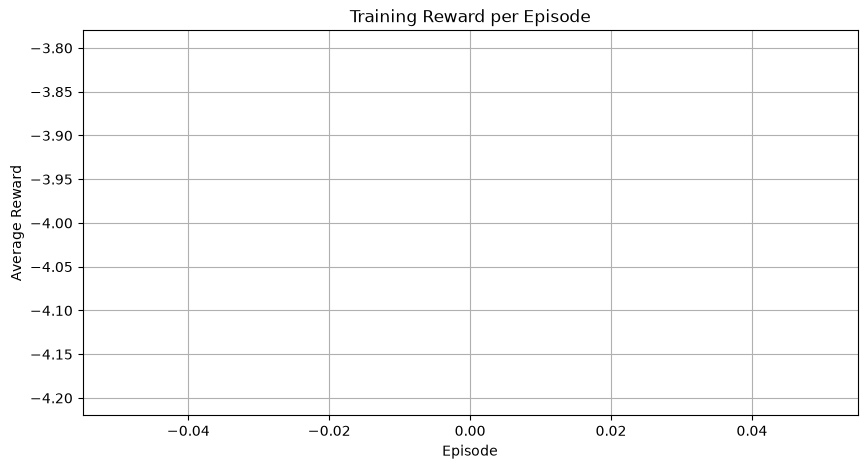

In [107]:
plt.figure(figsize=(10, 5))

plt.plot(
    episode_rewards,
    linewidth=2
)

plt.title("Training Reward per Episode")

plt.xlabel("Episode")

plt.ylabel("Average Reward")

plt.grid(True)

plt.show()

## Reward Statistics

In [108]:
print(f"Maximum Reward : {max(episode_rewards):.2f}")

print(f"Minimum Reward : {min(episode_rewards):.2f}")

print(f"Average Reward : {sum(episode_rewards) / len(episode_rewards):.2f}")

Maximum Reward : -4.00
Minimum Reward : -4.00
Average Reward : -4.00


## Performance Statistics

In [109]:
total_deliveries = delivery_count_A + delivery_count_B

print("=" * 60)
print("📊 PERFORMANCE STATISTICS")
print("=" * 60)

print(f"🤖 Agent A Deliveries : {delivery_count_A}")
print(f"🤖 Agent B Deliveries : {delivery_count_B}")
print(f"📦 Total Deliveries   : {total_deliveries}")

print(f"💥 Collision Count    : {collision_count}")

print(f"🌊 Water Damage Count : {water_damage_count}")

print("=" * 60)

📊 PERFORMANCE STATISTICS
🤖 Agent A Deliveries : 0
🤖 Agent B Deliveries : 0
📦 Total Deliveries   : 0
💥 Collision Count    : 0
🌊 Water Damage Count : 0


## Lake Statistics

In [110]:
lake_status = "🌊 FLOODED" if lake_state == FLOODED else "🟩 DRY"

print("🏞️ Lake Statistics")
print("-" * 30)
print(f"Final Lake State : {lake_status}")
print(f"Lake Flip Probability : {LAKE_FLIP_PROBABILITY}")

🏞️ Lake Statistics
------------------------------
Final Lake State : 🌊 FLOODED
Lake Flip Probability : 0.2


## Mission Statistics

In [111]:
print("🎯 Mission Results")
print("-" * 30)

print(
    f"Agent A Mission : {'✅ Completed' if mission_complete_A else '❌ Failed'}"
)

print(
    f"Agent B Mission : {'✅ Completed' if mission_complete_B else '❌ Failed'}"
)

🎯 Mission Results
------------------------------
Agent A Mission : ❌ Failed
Agent B Mission : ❌ Failed


## Final Performance

In [112]:
total_steps = step + 1

if mission_complete_A and mission_complete_B:
    success_rate = 100
elif mission_complete_A or mission_complete_B:
    success_rate = 50
else:
    success_rate = 0

## Overall Performance Summary

In [113]:
print("=" * 60)
print("🏆 FINAL PERFORMANCE SUMMARY")
print("=" * 60)

print(f"🚶 Total Steps           : {total_steps}")
print(f"📦 Total Deliveries      : {delivery_count_A + delivery_count_B}")
print(f"💥 Total Collisions      : {collision_count}")
print(f"🌊 Water Damage Events   : {water_damage_count}")
print(f"🎯 Mission Success Rate  : {success_rate}%")

print("=" * 60)

🏆 FINAL PERFORMANCE SUMMARY
🚶 Total Steps           : 100
📦 Total Deliveries      : 0
💥 Total Collisions      : 0
🌊 Water Damage Events   : 0
🎯 Mission Success Rate  : 0%


## Performance Evaluation

In [114]:
if success_rate == 100:
    print("✅ Excellent Performance")
elif success_rate >= 50:
    print("🟡 Good Performance")
else:
    print("🔴 Needs Improvement")

🔴 Needs Improvement
